In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/archive.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
import os
os.listdir("/content/data")

['ratings_Electronics (1).csv']

In [5]:
cols = ["user_id", "productId", "rating", "timestamp"]

In [6]:
df = pd.read_csv(
    "/content/data/ratings_Electronics (1).csv",
    header=None,
    names=cols
)

In [7]:
df.head()

,user_id,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [8]:
df.shape

(7824482, 4)

In [9]:
df.dtypes

,0
user_id,object
productId,object
rating,float64
timestamp,int64


In [10]:
df.isna().sum()

,0
user_id,0
productId,0
rating,0
timestamp,0


In [11]:
df["review_time"] = pd.to_datetime(df["timestamp"], unit="s")
df["year"] = df["review_time"].dt.year
df["quarter"] = df["review_time"].dt.quarter
df["month"] = df["review_time"].dt.month

df[["timestamp", "review_time", "year", "quarter", "month"]].head()

,timestamp,review_time,year,quarter,month
0,1365811200,2013-04-13,2013,2,4
1,1341100800,2012-07-01,2012,3,7
2,1367193600,2013-04-29,2013,2,4
3,1374451200,2013-07-22,2013,3,7
4,1334707200,2012-04-18,2012,2,4


In [12]:
q2_2014 = df[(df["year"] == 2014) & (df["quarter"] == 2)]

In [13]:
q2_2014.shape

(664014, 8)

In [14]:
q2_2014.head()

,user_id,productId,rating,timestamp,review_time,year,quarter,month
5,A1QGNMC6O1VW39,0511189877,5.0,1397433600,2014-04-14,2014,2,4
6,A3J3BRHTDRFJ2G,0511189877,2.0,1397433600,2014-04-14,2014,2,4
10,AZYNQZ94U6VDB,0511189877,5.0,1401321600,2014-05-29,2014,2,5
26,AYTBGUX49LF3W,0528881469,4.0,1398470400,2014-04-26,2014,2,4
55,A3ILG56NE5QU37,0594033896,5.0,1399420800,2014-05-07,2014,2,5


In [15]:
q2_2014.info()

<class 'pandas.core.frame.DataFrame'>
Index: 664014 entries, 5 to 7824477
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   user_id      664014 non-null  object        
 1   productId    664014 non-null  object        
 2   rating       664014 non-null  float64       
 3   timestamp    664014 non-null  int64         
 4   review_time  664014 non-null  datetime64[ns]
 5   year         664014 non-null  int32         
 6   quarter      664014 non-null  int32         
 7   month        664014 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(2)
memory usage: 38.0+ MB


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df_q2 = q2_2014.copy()

In [18]:
df_q2['rating'] = pd.to_numeric(df_q2['rating'], errors='coerce')

In [19]:
print(df_q2['rating'].isna().sum())
print(len(df_q2))

0
664014


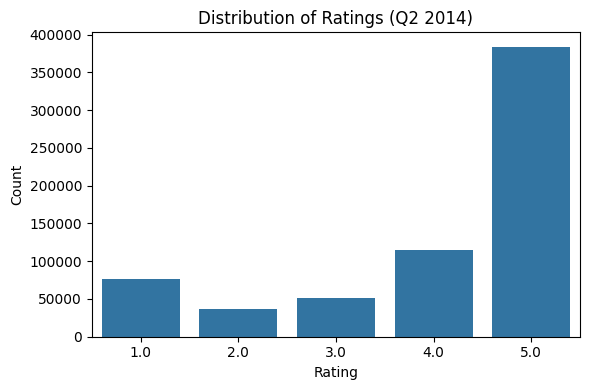

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df_q2)
plt.title('Distribution of Ratings (Q2 2014)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
high = q2_2014[q2_2014["rating"] >= 3]

print("High group size:", high.shape[0])

High group size: 549939


In [22]:
low = q2_2014[q2_2014["rating"] < 3]

print("Low group size:", low.shape[0])

Low group size: 114075


In [23]:
q2_2014["rating"].value_counts().sort_index()

,count
rating,
1.0,76769
2.0,37306
3.0,51802
4.0,114235
5.0,383902


In [24]:
# Adding group labels
low = low.copy()
high = high.copy()

low['rating_group'] = 'Low (<3)'
high['rating_group'] = 'High (>=3)'

# Combine
df_combined = pd.concat([low, high])

In [25]:
reviews_per_product = df_combined.groupby(['productId', 'rating_group']) \
                                 .size() \
                                 .reset_index(name='review_count')

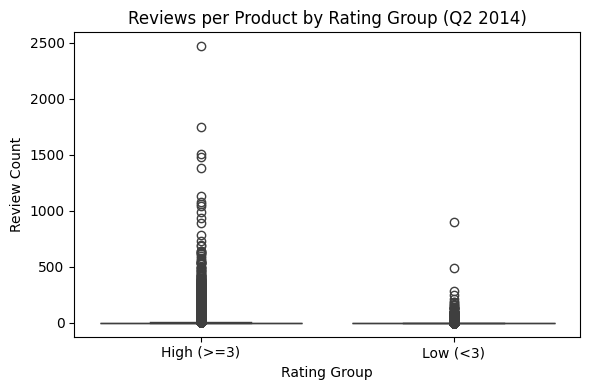

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rating_group', y='review_count', data=reviews_per_product)
plt.title('Reviews per Product by Rating Group (Q2 2014)')
plt.xlabel('Rating Group')
plt.ylabel('Review Count')
plt.tight_layout()
plt.show()

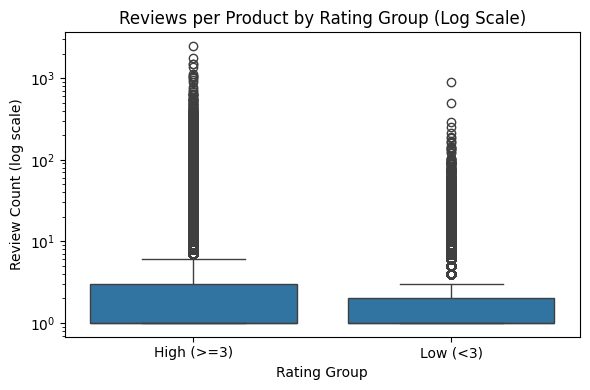

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rating_group', y='review_count', data=reviews_per_product)

plt.yscale('log')

plt.title('Reviews per Product by Rating Group (Log Scale)')
plt.xlabel('Rating Group')
plt.ylabel('Review Count (log scale)')
plt.tight_layout()
plt.show()

In [28]:
high_counts = high.groupby("productId").size()

high_counts.head()

,0
productId,
0511189877,2
0528881469,1
0594033896,1
0594033926,5
0594033934,1


In [29]:
low_counts = low.groupby("productId").size()

low_counts.head()

,0
productId,
0511189877,1
0594033926,1
0594451647,1
0594481902,1
0972683275,1


In [30]:
print("High group summary")
print(high_counts.describe())

print("\nLow group summary")
print(low_counts.describe())

High group summary
count    107281.000000
mean          5.126155
std          23.851303
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        2468.000000
dtype: float64

Low group summary
count    42955.000000
mean         2.655686
std          7.857264
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        903.000000
dtype: float64


In [31]:
from scipy import stats

In [32]:
t_stat, p_value = stats.ttest_ind(high_counts, low_counts, equal_var=False)

print("Welch t-statistic:", t_stat)
print("p-value:", p_value)

Welch t-statistic: 30.091901799832016
p-value: 2.5006391891054197e-198


In [33]:
print("Distinct high-rated products:", high["productId"].nunique())
print("Distinct low-rated products:", low["productId"].nunique())

Distinct high-rated products: 107281
Distinct low-rated products: 42955


In [34]:
print("Top high-rated products")
print(high_counts.sort_values(ascending=False).head(10))

print("\nTop low-rated products")
print(low_counts.sort_values(ascending=False).head(10))

Top high-rated products
productId
B00DR0PDNE    2468
B007WTAJTO    1750
B009SYZ8OC    1504
B00GTGETFG    1484
B003ES5ZUU    1381
B005X1Y7I2    1136
B003ELYQGG    1077
B00E3W15P0    1058
B009A5204K    1047
B00BGGDVOO     992
dtype: int64

Top low-rated products
productId
B00A3YN0Z0    903
B00DR0PDNE    493
B009A5204K    289
B009SYZ8OC    251
B0092HP3EA    215
B008GVM9K4    189
B00E98O7GC    183
B007WTAJTO    168
B00CAFPF26    163
B000I68BD4    161
dtype: int64
